# Cooke Triplet — Chief-Ray Distortion

A classic three-element photographic objective (H. Dennis Taylor, 1893):
positive-negative-positive, stop between the second and third elements.
Prescription reconstructed from the "oslo cooke triplet example 50mm f/4
20deg" reference lens distributed with the open-source
[rayopt-notebooks](https://github.com/quartiq/rayopt-notebooks) project
(`triplet.ipynb`); glass indices (SK16, F4) are d-line (587.6 nm) values
from the SCHOTT optical glass pocket catalog. It is a textbook-scale
example, not a claim of a specific commercial lens.

The triplet's asymmetric aperture-stop position (offset toward the rear,
between the negative and rear positive elements) is the classic source of
a small but nonzero *linear* asymmetry in the object-to-image map — this
notebook measures it directly with the chief-ray distortion metric, both
as a dense distortion-vs-field curve and as the classic warped-grid
display used in optical design software.

In [1]:
from importlib import resources
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.sequential import (
    FieldPoint, OpticalSystem, ParaxialModel, SequentialTracer,
    chief_ray_slopes, solve_object_plane, trace_from_object,
)
from raytracer.analysis import distortion_grid
from raytracer.viz import plots

CSV = resources.files("raytracer") / "data" / "cooke_triplet_prescription.csv"
system = OpticalSystem.from_prescription(CSV)
tracer = SequentialTracer(system)
conjugate = solve_object_plane(tracer)
efl = ParaxialModel(system).effective_focal_length()

print(f"{len(system)} surfaces, stop at index {system.stop_index}")
print(f"EFL = {efl:.3f} mm (design: 50 mm)")
print(f"recovered object plane z = {conjugate.object_z:.1f} mm "
      f"(a large finite stand-in for the design's object at infinity)")
print(f"magnification = {conjugate.magnification:.6f}")

7 surfaces, stop at index 4
EFL = 50.056 mm (design: 50 mm)
recovered object plane z = 13096.0 mm (a large finite stand-in for the design's object at infinity)
magnification = 0.003812


## Distortion vs. field angle

The object is effectively at infinity, so field points are parametrized by
angle rather than object height (matching the design's own convention:
"50mm f/4 20deg" — a 20° total field, i.e. a 10° half field). Each angle
converts to an object height at the recovered finite conjugate; the chief
ray (through the aperture-stop center) is solved with the general 2-D
solver `chief_ray_slopes`, and its image-plane height is compared against
the ideal `magnification * y` line.

The curve is sampled densely (steps of 0.5°) out to a bit past the
design's stated 10° half field, not just at a handful of points, so the
shape of the curve — not just a few widely-spaced dots — is what carries
the result.

 field (deg) |  image y (mm) |  distortion (um) | relative (ppm)
         0.0 |        0.0000 |            0.000 |            0.0
         2.0 |        1.7431 |            0.053 |           30.5
         4.0 |        3.4905 |            0.435 |          124.6
         6.0 |        5.2465 |            1.520 |          289.8
         8.0 |        7.0154 |            3.787 |          539.9
        10.0 |        8.8017 |            7.890 |          896.4
        12.0 |       10.6102 |           14.764 |         1391.5


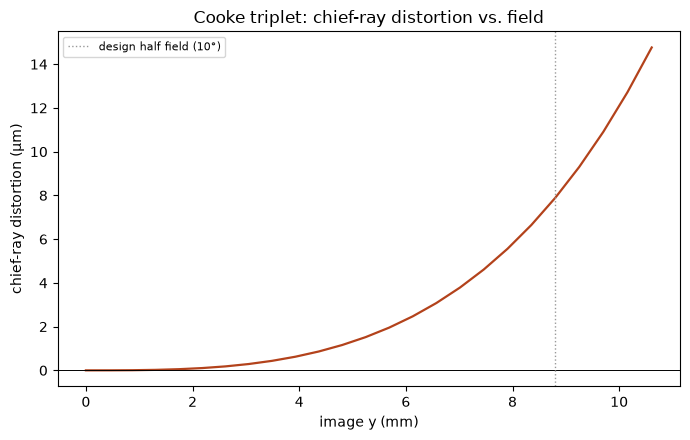

In [2]:
from raytracer.analysis import chief_ray_distortion

FIELDS_DEG = np.arange(0.0, 12.01, 0.5)
rows = chief_ray_distortion(
    tracer, FIELDS_DEG, magnification=conjugate.magnification, field_unit="deg",
)
image_heights = [r["paraxial_image_height_mm"] for r in rows]
distortions_um = [r["chief_ray_distortion_um"] for r in rows]

print(f"{'field (deg)':>12} | {'image y (mm)':>13} | {'distortion (um)':>16} | {'relative (ppm)':>14}")
for r in rows[::4]:
    print(f"{r['field']:12.1f} | {r['paraxial_image_height_mm']:13.4f} | "
          f"{r['chief_ray_distortion_um']:16.3f} | {r['chief_ray_relative_distortion_ppm']:14.1f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(image_heights, distortions_um, "-", color="#b3421b", lw=1.6)
ax.axhline(0, color="black", lw=0.7)
ax.axvline(abs(conjugate.object_z) * np.tan(np.deg2rad(10.0)) * conjugate.magnification,
           color="#999999", ls=":", lw=1, label="design half field (10\u00b0)")
ax.set(xlabel="image y (mm)", ylabel="chief-ray distortion (\u00b5m)",
       title="Cooke triplet: chief-ray distortion vs. field")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Distortion grid

The classic optical-design-software display: trace a square grid of
object points and see how it warps at the image plane. The grid spans the
design's 10° half field on each axis; distortion at this scale is far too
small to see at 1:1, so it is shown exaggerated (with the true-scale panel
alongside for reference).

grid coverage: 100.0% of 121 points traced without vignetting


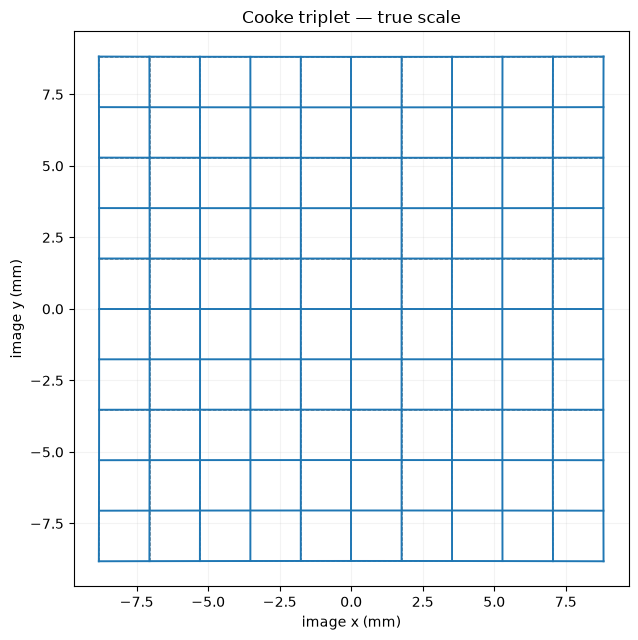

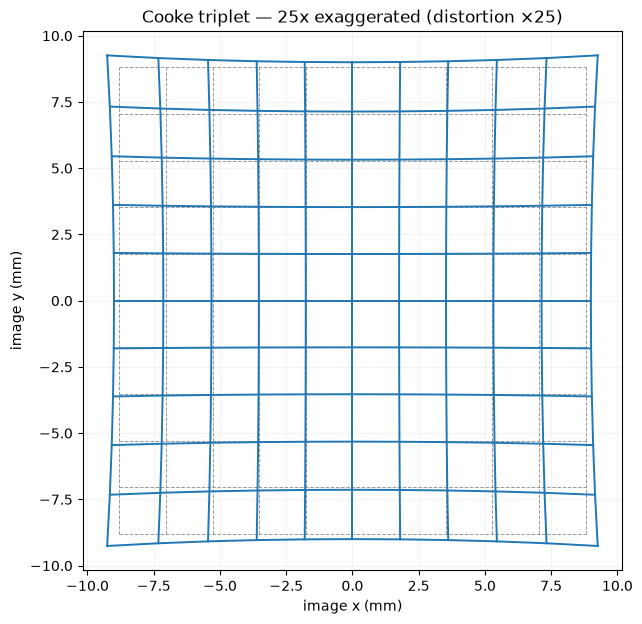

In [3]:
half = abs(conjugate.object_z) * np.tan(np.deg2rad(10.0))
grid = distortion_grid(tracer, magnification=conjugate.magnification, half_field=half, n=11)
print(f"grid coverage: {grid.valid_fraction:.1%} of {grid.valid.size} points traced without vignetting")

fig = plots.distortion_grid_figure(grid, exaggeration=1.0, title="Cooke triplet — true scale")
plt.show()
fig = plots.distortion_grid_figure(grid, exaggeration=25.0, title="Cooke triplet — 25x exaggerated")
plt.show()

## Seidel-style aberration coefficients

Deduced from the exact-ray-traced wavefront (`seidel_coefficients`), not
from a paraxial surface-by-surface formula: at each of several field
heights, the wavefront is reconstructed from transverse ray aberrations
and its low-order Zernike modes converted back to the classical
monomial (Seidel) basis. Coma and astigmatism are expected to grow with
field (linearly and quadratically); spherical is expected to be roughly
field-independent for a simple, unaspherized design like this one.

na_object_sine = 4.96e-04, na_image = 0.1302 (expect ~0.125 for f/4)


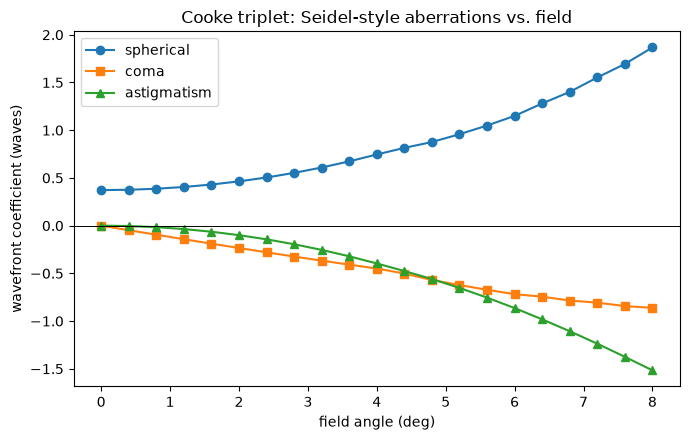

spherical (field-independent):  +0.8650 waves
coma (per unit field height):   -0.0005 waves/mm
astigmatism (per h^2):          -0.0000 waves/mm^2
field curvature (per h^2):      +0.0000 waves/mm^2
(design defocus offset:         -1.3838 waves)


In [4]:
from raytracer.analysis import seidel_coefficients

na_object_sine = 6.5 / abs(conjugate.object_z)  # entrance pupil radius / object distance
na_image = na_object_sine / abs(conjugate.magnification)  # ~f/4 image-side NA
print(f"na_object_sine = {na_object_sine:.2e}, na_image = {na_image:.4f} (expect ~0.125 for f/4)")

seidel_fields_deg = np.linspace(0.0, 8.0, 21)
seidel_fields_mm = np.abs(conjugate.object_z) * np.tan(np.deg2rad(seidel_fields_deg))
seidel = seidel_coefficients(
    tracer, seidel_fields_mm, na_object_sine=na_object_sine, na_image=na_image,
    wavelength_mm=0.5876e-3,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(seidel_fields_deg, seidel.spherical_waves, "o-", label="spherical")
ax.plot(seidel_fields_deg, seidel.coma_waves, "s-", label="coma")
ax.plot(seidel_fields_deg, seidel.astigmatism_waves, "^-", label="astigmatism")
ax.axhline(0, color="black", lw=0.7)
ax.set(xlabel="field angle (deg)", ylabel="wavefront coefficient (waves)",
       title="Cooke triplet: Seidel-style aberrations vs. field")
ax.legend()
fig.tight_layout()
plt.show()

print(seidel.summary())

## Chromatic aberration (axial + lateral color)

SK16 now resolves to a real measured `SellmeierMaterial` (SCHOTT catalog
coefficients); F4 has no verified Sellmeier data available and stays an
`AbbeMaterial` approximation from its catalog nd/Vd (see
`raytracer.core.materials`). Both give a genuine `n(lambda)` curve, not a
single fixed index, so the same prescription can be retraced across the
visible spectrum: axial color (the paraxial focus shifting with
wavelength) and lateral color (the chief ray's image height, at the
d-line's own focal plane, shifting with wavelength for an off-axis field
point). F/d/C are marked for reference, but the curves are sampled
densely across 400-700 nm, not just at those three points.

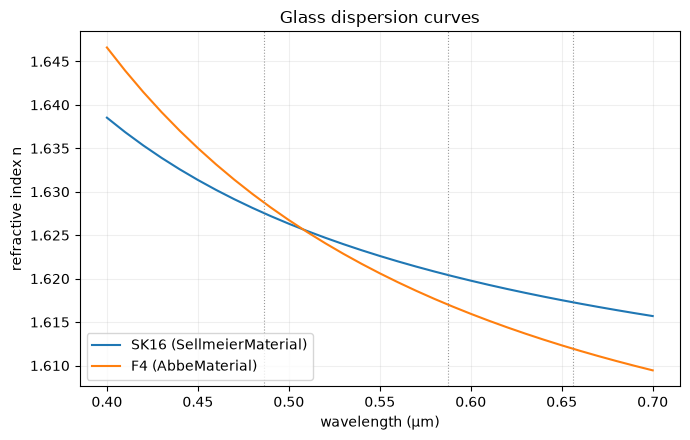

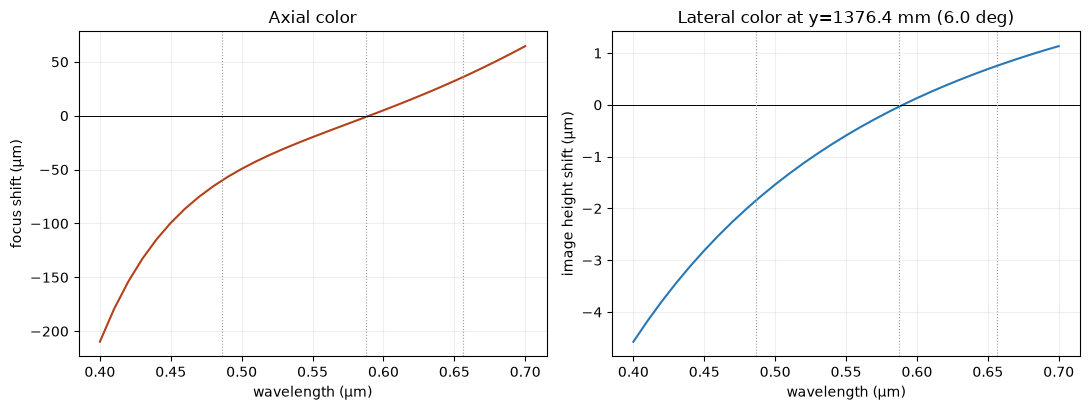

axial color (F to C):                -95.13 um
lateral color (F to C) at 6.0 deg:  -2.550 um


In [5]:
from raytracer.analysis import axial_color, lateral_color
from raytracer.core.materials import default_materials

WAVELENGTHS_UM = np.linspace(0.40, 0.70, 31)
F_LINE, D_LINE, C_LINE = 0.48613, 0.58756, 0.65627

materials = default_materials()
fig, ax = plt.subplots(figsize=(7, 4.5))
for name in (('SK16', 'F4')):
    glass = materials.resolve(name)
    n = [glass.index(wl) for wl in WAVELENGTHS_UM]
    ax.plot(WAVELENGTHS_UM, n, "-", label=f"{name} ({type(glass).__name__})")
for wl, label in [(F_LINE, "F"), (D_LINE, "d"), (C_LINE, "C")]:
    ax.axvline(wl, color="#999999", ls=":", lw=0.8)
ax.set(xlabel="wavelength (µm)", ylabel="refractive index n", title="Glass dispersion curves")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

ac = axial_color(system, WAVELENGTHS_UM, reference_wavelength_um=D_LINE)
y_field = np.abs(conjugate.object_z) * np.tan(np.deg2rad(6.0))
lc = lateral_color(system, WAVELENGTHS_UM, field_height_mm=y_field, reference_wavelength_um=D_LINE)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(WAVELENGTHS_UM, ac.focus_shift_mm * 1e3, "-", color="#b3421b")
axes[0].axhline(0, color="black", lw=0.7)
axes[1].plot(WAVELENGTHS_UM, lc.lateral_color_um, "-", color="#2878b5")
axes[1].axhline(0, color="black", lw=0.7)
for ax, title, ylabel in [
    (axes[0], "Axial color", "focus shift (µm)"),
    (axes[1], f"Lateral color at y={y_field:.1f} mm (6.0 deg)", "image height shift (µm)"),
]:
    for wl in (F_LINE, D_LINE, C_LINE):
        ax.axvline(wl, color="#999999", ls=":", lw=0.8)
    ax.set(xlabel="wavelength (µm)", ylabel=ylabel, title=title)
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

f_idx = int(np.argmin(np.abs(WAVELENGTHS_UM - F_LINE)))
c_idx = int(np.argmin(np.abs(WAVELENGTHS_UM - C_LINE)))
print(f"axial color (F to C):                {(ac.focus_shift_mm[f_idx] - ac.focus_shift_mm[c_idx]) * 1e3:+.2f} um")
print(f"lateral color (F to C) at 6.0 deg:  {(lc.lateral_color_um[f_idx] - lc.lateral_color_um[c_idx]):+.3f} um")
